XGBoost - Model Development Workflow

> **MLCourse · Machine Learning · supervised · regression**

The professional loop on REAL California-district data (`data/california_housing.csv`):
hold out a test set and NEVER touch it, carve a validation slice off the
TRAINING side to drive EARLY STOPPING, read the RMSE learning curve, audit
gain-based importances, and only then judge the model once on unseen districts.

## What you'll learn
1. Train/validation/test hygiene - two `train_test_split` calls, test untouched
2. `early_stopping_rounds` (constructor) + `eval_set` (fit) = automatic `n_estimators`
3. `evals_result()` → RMSE learning curve with the best iteration marked
4. Gain importances with fN→column-name remapping (boosters speak matrix, not pandas)

In [1]:
# --- Setup: imports, reproducibility, data resolution -----------------------
try:                                                # notebook nicety: inline
    get_ipython().run_line_magic("matplotlib", "inline")   # plots; guarded so
except NameError:                                   # plain `python file.py`
    pass                                            # runs still work

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

np.random.seed(42)                                  # reproducible everything
sns.set_theme()                                     # clean seaborn styling
plt.rcParams["figure.dpi"] = 100

# Walk up the directory tree until we find the root that owns data/.
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

# Real data only: fetch once from sklearn if the CSV isn't cached yet.
csv_path = ML_ROOT / "data" / "california_housing.csv"
if not csv_path.exists():
    from sklearn.datasets import fetch_california_housing   # download-once
    fetch_california_housing(as_frame=True).frame.to_csv(csv_path, index=False)

# Fixed 6000-row sample keeps this teaching run snappy (full data = hard project).
housing = pd.read_csv(csv_path).sample(n=6000, random_state=42).reset_index(drop=True)
print("xgboost workflow | rows:", len(housing), "| cols:", list(housing.columns))

xgboost workflow | rows: 6000 | cols: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


## 1. Question & quick EDA

**Question:** predict a district's median house value (`MedHouseVal`, in
$100k units) from demographics + geography. Before modeling: what does the
target look like, and which features move with it?

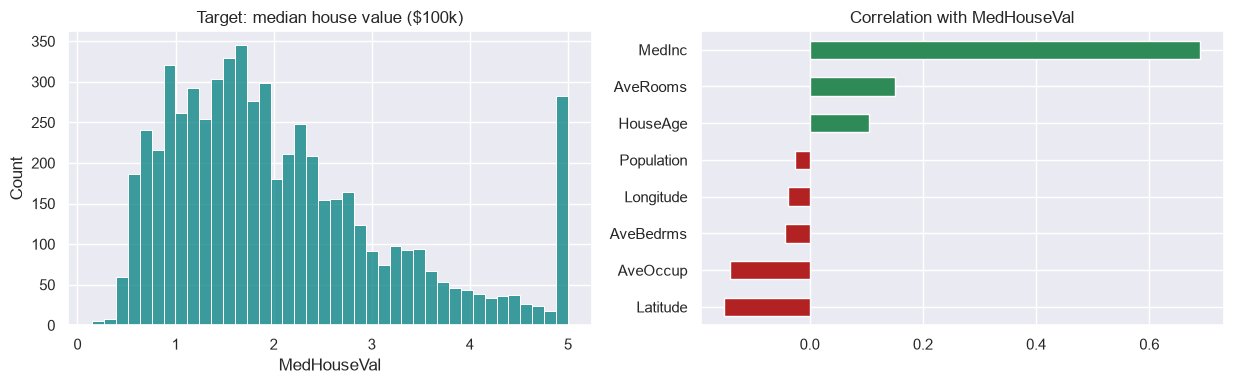

missing values: 0 | rows: 6000


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
sns.histplot(housing["MedHouseVal"], bins=40, ax=axes[0], color="teal")
axes[0].set_title("Target: median house value ($100k)")     # note the cap spike ~5.0!
corr = housing.corr()["MedHouseVal"].drop("MedHouseVal").sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in corr]
corr.plot(kind="barh", color=colors, ax=axes[1])
axes[1].set_title("Correlation with MedHouseVal")
plt.tight_layout()
plt.show()
print("missing values:", housing.isna().sum().sum(),          # XGB could eat them,
      "| rows:", len(housing))                                # but there are none

## 2. Split hygiene - carve validation OUT OF TRAIN, keep test sealed

Early stopping needs something to watch. If we watched the TEST set we'd be
leaking: round-count choices would secretly tune on the exam. So: split off
test FIRST and set it aside; then slice a validation chunk from what remains.

In [3]:
TARGET = "MedHouseVal"
y = housing[TARGET]                                   # Series of targets
X = housing.drop(columns=[TARGET])                    # feature frame (8 cols)

X_tr_full, X_te, y_tr_full, y_te = train_test_split(  # step 1: seal the test set
    X, y, test_size=.20, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(            # step 2: val FROM train only
    X_tr_full, y_tr_full, test_size=.25, random_state=42)  # → 60/20/20 overall

print(f"train {len(X_tr)} | validation {len(X_va)} | test {len(X_te)} (sealed)")

train 3600 | validation 1200 | test 1200 (sealed)


## 3. Fit with early stopping - patience lives in the CONSTRUCTOR (xgboost 3.x)

We budget 1500 rounds but expect far fewer: training halts when validation
RMSE stops improving for 60 straight rounds. ⚠️ Old tutorials pass
`early_stopping_rounds=` to `fit()` - that crashes on modern xgboost.

In [4]:
model = XGBRegressor(
    n_estimators=1500, learning_rate=.06,             # generous budget, small steps
    max_depth=5,                                      # interaction depth
    subsample=.85, colsample_bytree=.85,              # stochastic decorrelation
    early_stopping_rounds=60,                         # 3.x style: in constructor!
    eval_metric="rmse",                               # metric WATCHED for stopping
    objective="reg:squarederror",
    random_state=42)

model.fit(
    X_tr.values, y_tr.values,                         # matrices ⇒ get_score gives fN keys
    eval_set=[(X_va.values, y_va.values)],            # what early stopping watches
    verbose=False)                                    # silence per-round logging

print("stopped at round:", model.best_iteration,      # the REAL tree count
      "| best val RMSE:", round(model.best_score, 4))

stopped at round: 565 | best val RMSE: 0.4551


## 4. The learning curve - `evals_result()` tells the story

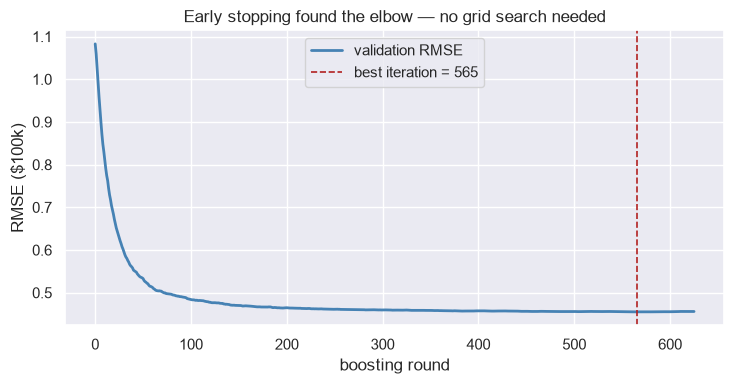

In [5]:
hist = model.evals_result()["validation_0"]["rmse"]   # METHOD in modern xgboost
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(hist, color="steelblue", lw=2, label="validation RMSE")
ax.axvline(model.best_iteration, color="firebrick", ls="--", lw=1.2,
           label=f"best iteration = {model.best_iteration}")
ax.set_xlabel("boosting round")
ax.set_ylabel("RMSE ($100k)")
ax.set_title("Early stopping found the elbow - no grid search needed")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Judge ONCE on the sealed test set

💡 MAE reads as typical dollar error; RMSE punishes big misses; R² says how
much variance we explain vs predicting the mean.

In [6]:
pred_te = model.predict(X_te.values)                  # one-shot evaluation
mae = mean_absolute_error(y_te, pred_te)              # avg $ error
rmse = root_mean_squared_error(y_te, pred_te)         # penalized $ error
r2 = r2_score(y_te, pred_te)                          # variance explained
print(f"test MAE : {mae:.4f}  (~${mae*100_000:,.0f} per district)")   # target unit = $100k
print(f"test RMSE: {rmse:.4f}")
print(f"test R^2 : {r2:.4f}")

test MAE : 0.3288  (~$32,878 per district)
test RMSE: 0.4842
test R^2 : 0.8281


## 6. Gain importances - remap fN codes back to real names

`get_score(importance_type="gain")` ranks features by how much squared-error
they removed. Because we fit on NumPy matrices, keys arrive as `f0…f7` -
WE own the mapping back to column names.

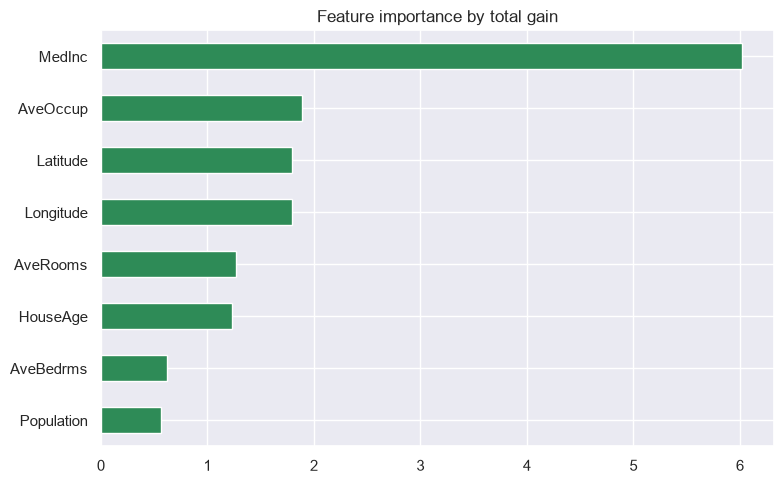

[tip] Median income dominates - geography (Latitude/Longitude) and occupancy
   fill in the rest. Matches the correlation picture from EDA.


In [7]:
raw = model.get_booster().get_score(importance_type="gain")
name_of = {f"f{i}": col for i, col in enumerate(X.columns)}   # rebuild the bridge
imp = pd.Series({name_of.get(k, k): v                 # .get() tolerates either key
                 for k, v in raw.items()}).sort_values()

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="seagreen")
plt.title("Feature importance by total gain")
plt.tight_layout()
plt.show()
print("[tip] Median income dominates - geography (Latitude/Longitude) and occupancy")
print("   fill in the rest. Matches the correlation picture from EDA.")

## 7. Actual vs predicted - where does it miss?

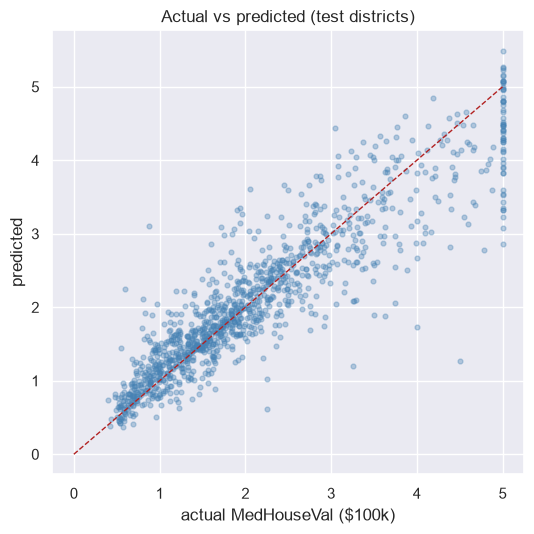

[tip] Misses cluster near the 5.0 ceiling - capped labels can't be exceeded;
   the hard project investigates exactly that.


In [8]:
lims = [0, y_te.max()]                                # shared axis range
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_te, pred_te, s=12, alpha=.35, color="steelblue")
plt.plot(lims, lims, color="firebrick", ls="--", lw=1)  # perfect-prediction line
plt.xlabel("actual MedHouseVal ($100k)")
plt.ylabel("predicted")
plt.title("Actual vs predicted (test districts)")
plt.tight_layout()
plt.show()
print("[tip] Misses cluster near the 5.0 ceiling - capped labels can't be exceeded;")
print("   the hard project investigates exactly that.")

## Summary & key takeaways

- Validation drives early stopping; test stays sealed for ONE final verdict.
- In xgboost 3.x: patience/eval_metric go in the CONSTRUCTOR, `eval_set`
  rides in `fit(..., verbose=False)`, history comes from `evals_result()`.
- Gain importances need an fN→name remap when you fit on arrays.
- A depth-5, lr-0.06 early-stopped booster lands around R² ≈ 0.80 on this
  sample with zero manual tuning of tree count.